In [1]:
using GLPK, JuMP, Plots
using Measures
# import Pkg
# Pkg.add("Measures")
# using Random
# Random.seed!(42)

# Model

The goal is to determine the optimal heat production schedule for a simplified system with three different heat sources \(and a storage\).

- **Biomass boiler**
- **Gas boiler**
- **Heat pump** (waterbased, so no variation in resource)

Two models are considered:

- **Model 1** – without thermal storage
- **Model 2** – with thermal storage (150 MW)

**Only operating costs are minimized.**  -  Not considered: Sustainability, political constraints, taxes, subsidies, investment costs etc.


---

# Assumptions:
- Time discretization: **24 discrete time steps**, all time steps have **equal** duration.
- The **heat demand** is known perfectly in advance. (No uncertainty or forecast error is considered)
- Maximum demand: **450 MW**

For all three units:

- Installed capacity: **150 MW**
- Heat production is continous
- Each unit has:
  - **constant** operating costs (Electricity, biomass and gas prices are therefore assumed to be constant.)
  - fixed ramp-up and fixed ramp-down limit
- 100% availability
---

**Not considered:**
- start-up and shut-down costs
- minimum operating power 
- unexpected outages or failures 

---



In [2]:
#DATA
N = 24      # amount timesteps   
M = 3       # amount heatsources

# 1 biomass boiler
# 2 gas boiler
# 3 heat pump

c = [185, 600, 260]         # Cost           - DKK / MWh
m = [150, 150, 150]         # Capacity          - MW
ramp_up = [30,100,60]       # Heat-up-speed     - MW / time step
ramp_down = [10,100,60];    # Cool-down-speed   - MW / time step


# DEMAND
# d = rand(0:450, N)                    # random
# d = [                             
#     220, 210, 205, 200, 210, 250,     # typical day
#     310, 360, 380, 370, 340, 320,
#     300, 290, 285, 300, 330, 370,
#     400, 390, 350, 310, 270, 240]
d = [370, 200, 230, 270, 450, 280, 240, 210, 370, 190, 180, 200, 0, 270, 300, 280, 240, 210, 260, 190,0,450,0,100];   # MW 

In [3]:
model1 = Model(GLPK.Optimizer)

@variable(model1, x1[1:M,1:N] >= 0)

# minimize COST
@objective( model1, Min, sum(  sum(x1[j,i]*c[j] for i=1:N)   for j=1:M   ))

# CONSTRAINTS
# capacity
@constraint(model1, [j=1:M,i=1:N], x1[j,i] <= m[j])
# meet Demand
@constraint(model1, [i=1:N],   sum( x1[j,i] for j=1:M) >= d[i]    )
# ramp_up/down
@constraint(model1, [j=1:M, i=2:N],  x1[j,i] - x1[j,i-1] <= ramp_up[j])
@constraint(model1, [j=1:M, i=2:N],  x1[j,i-1] - x1[j,i] <= ramp_down[j])

optimize!(model1)

println("Solver status: ", termination_status(model1))
println("Solution status: ", primal_status(model1))
## Printing the solution
println("Objective value = ", objective_value(model1)) 

cost1 = 0
for j=1:M
    for i=1:N
        print(round(value(x1[j,i]),digits=2),"\t")
        cost1 += value(x1[j,i])*c[j]
    end
    println()
end
cost_Euro = round(cost1/7.5,digits=2)
println("Cost: ",cost1/1000000, " Million DKK \t (",cost_Euro, " in €)")

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 1.6141e6
150.0	140.0	140.0	130.0	150.0	140.0	150.0	140.0	150.0	140.0	140.0	130.0	120.0	150.0	150.0	150.0	150.0	150.0	140.0	130.0	120.0	150.0	140.0	130.0	
70.0	0.0	0.0	50.0	150.0	50.0	0.0	0.0	90.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	50.0	150.0	50.0	0.0	
150.0	90.0	90.0	90.0	150.0	90.0	90.0	70.0	130.0	70.0	40.0	70.0	60.0	120.0	150.0	130.0	90.0	60.0	120.0	60.0	90.0	150.0	90.0	30.0	
Cost: 1.6141 Million DKK 	 (215213.33 in €)


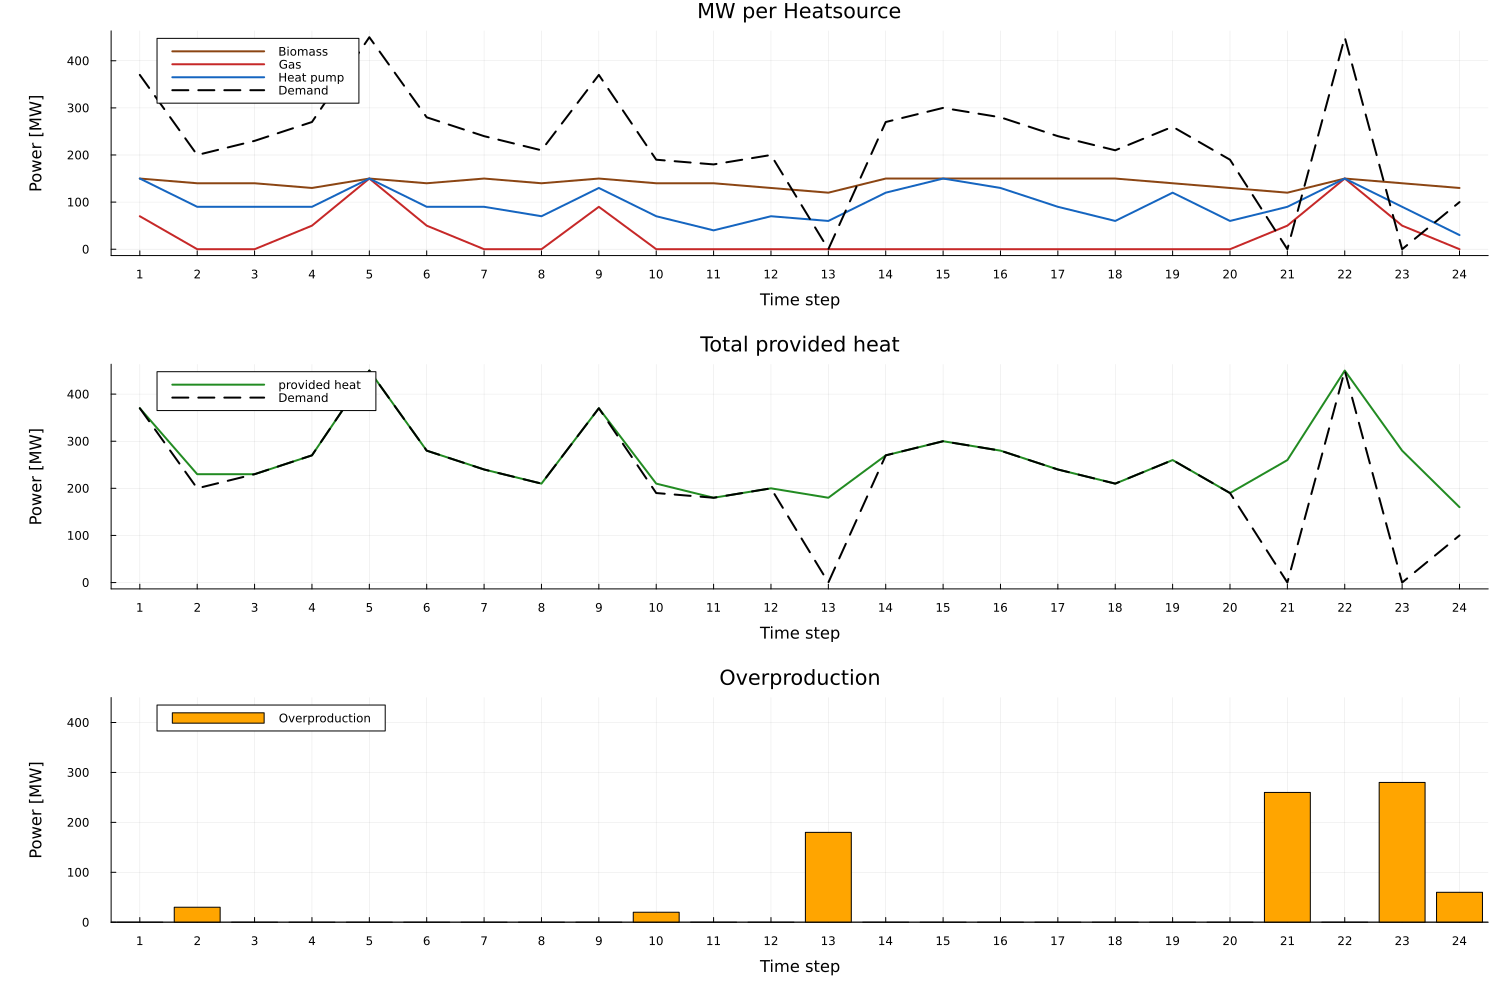

In [ ]:
# plot opt1
xmin = 0.5
xmax = N + 0.5
# Biomass - forest green
# Gas - dark red
# Heat pump - blue

# 1. HEAT SOURCES
p = plot( 1:N, 
        [value.(x1[j,:]) for j in 1:3], 
        labels=["Biomass" "Gas" "Heat pump"], 
        color = ["#8B4513" "#C62828" "#1565C0"],
        xlabel="Time step", 
        ylabel="Power [MW]", 
        lw=2 , 
        title="MW per Heatsource",
        xticks=1:N,
        grid=true,
        xlims = (xmin,xmax))
plot!(p, 1:N, 
        d, 
        label="Demand", 
        lw=2, 
        linestyle=:dash,
        color=:black )

# 2. TOTAL PROVIDED HEAT
x1_result = value.(x1)

total = zeros(N)
for i=1:M
    total = total .+ x1_result[i,:]
end

p_total = plot(1:N, total, label="provided heat", lw=2,
        title="Total provided heat",
        color="#228B22",
        xticks=1:N,
        grid=true,
        xlims = (xmin,xmax),
        legend=:topleft)
plot!(p_total, 1:N, d,   label="Demand", lw=2, linestyle=:dash,color=:black)

xlabel!(p_total, "Time step")
ylabel!(p_total, "Power [MW]")

# 3. OVERPRODUCTION
ymax = maximum(d)
overproduction = max.(total .- d, 0)

p_overproduction = bar(1:N,
    overproduction,
    label="Overproduction",
    color=:orange,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Overproduction",
    xticks=1:N,
    ylims=(0,ymax),
    grid=true,
    xlims = (xmin,xmax),
    legend=:topleft)

hline!(
    p_overproduction,
    [0],
    color=:black,
    lw=1,
    label="")

p_combined = plot( p,p_total,p_overproduction,
    layout=@layout([
        a 
        b
        e
    ]),    
    link=:x,
    left_margin=12mm,
    bottom_margin=8mm,
    size=(1500,1000))

display(p_combined)


## Thermal storage

**For Model 2:**

- Maximum storage capacity: **150 MWh**
- Initial storage level: **75 MWh** (Final storage level must equal the initial storage level)
- Maximum charging power: **75 MW**
- Maximum discharging power: **75 MW**
- Charging efficiency: **95 %**
- Discharging efficiency: **95 %**
- No standing losses are considered. 
- Charging and discharging are continuously.
- **Excess heat** may be discarded if it cannot be used or stored.

In [5]:
# 2opt
#THERMAL STORAGE
E_maxCharge = 75        # MW
E_maxDischarge = 75     # MW   
E_max = 150             # Storage Capacity  - MWh
E_start = 75           # Start Capacity    - MWh   

eff_charge = 0.95        # Heat loss while charging        
eff_discharge = 0.95     # Heat loss while discharging
eff_storage = 1.        # Heat loss while storing       - no influence!


using GLPK, JuMP, Plots
model2 = Model(GLPK.Optimizer)

@variable(model2, x2[1:3,1:N] >= 0)

@variable(model2, E[1:N] >= 0)
@variable(model2, charge[1:N] >= 0)
@variable(model2, discharge[1:N] >= 0)
@variable(model2, excessHeat[1:N] >= 0)

# KOSTEN minimieren
@objective(model2, Min, sum( sum(x2[j,t]*c[j] for t=1:N) for j=1:M))
# CONSTRAINTS:
# kann maximalen Wirkungsgrad nicht übersteigen    -    je Heizquelle
@constraint(model2, [j=1:M,t=1:N], x2[j,t] <= m[j])
# DEMAND hast to be met     -    für alle Zeitpunkte i
# @constraint(model, [t=1:N],   sum( x2[j,t] for j=1:M) >= d[t]    )

# heating speed
@constraint(model2, [j=1:M, t=2:N],  x2[j,t] - x2[j,t-1] <= ramp_up[j])
@constraint(model2, [j=1:M, t=2:N],  x2[j,t-1] - x2[j,t] <= ramp_down[j])

# SPEICHER
@constraint(model2, [t=1:N], charge[t]    <= E_maxCharge)                                 # charging-speed
@constraint(model2, [t=1:N], discharge[t] <= E_maxDischarge)
@constraint(model2, [t=1:N], E[t]         <= E_max)                                       # storage-capazity
@constraint(model2, [t=1:N], sum( x2[i,t] for i=1:M) + discharge[t] == d[t] + charge[t] + excessHeat[t])      # heat-equality

@constraint(model2, [t=2:N], E[t] == eff_storage * E[t-1] + eff_charge * charge[t] - 1/eff_discharge * discharge[t])          # keep track of storage
@constraint(model2, E[1] == E_start + eff_charge * charge[1] - 1/eff_discharge * discharge[1])
@constraint(model2, E[N] == E_start)



optimize!(model2)

println("Solver status: ", termination_status(model2))
println("Solution status: ", primal_status(model2))
## Printing the solution
println("Objective value = ", objective_value(model2)) 

cost2 = 0
for j=1:M
    for i=1:N
        print(round(value(x2[j,i]),digits=2),"\t")
        cost2 += value(x2[j,i])*c[j]
    end
    println()
end
cost2_Euro = round(cost2/7.5,digits=2)
println("\nCost: ",round(cost2/1000000,digits=4), " Million DKK \t (",cost2_Euro, " in €)\n")

println("Excess Heat:\n",round.(value.(excessHeat),digits=2))

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 1.3214327423822714e6
150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	140.0	130.0	120.0	150.0	150.0	150.0	150.0	150.0	140.0	130.0	120.0	150.0	140.0	130.0	
0.0	0.0	0.0	0.0	75.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	100.0	0.0	0.0	
150.0	90.0	91.72	150.0	150.0	130.0	137.56	90.0	150.0	90.0	34.5	60.0	0.0	60.0	120.0	130.0	90.0	60.0	120.0	60.0	65.0	125.0	65.0	5.0	

Cost: 1.3214 Million DKK 	 (176191.03 in €)

Excess Heat:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 45.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 110.0, 0.0, 161.05, 0.0]


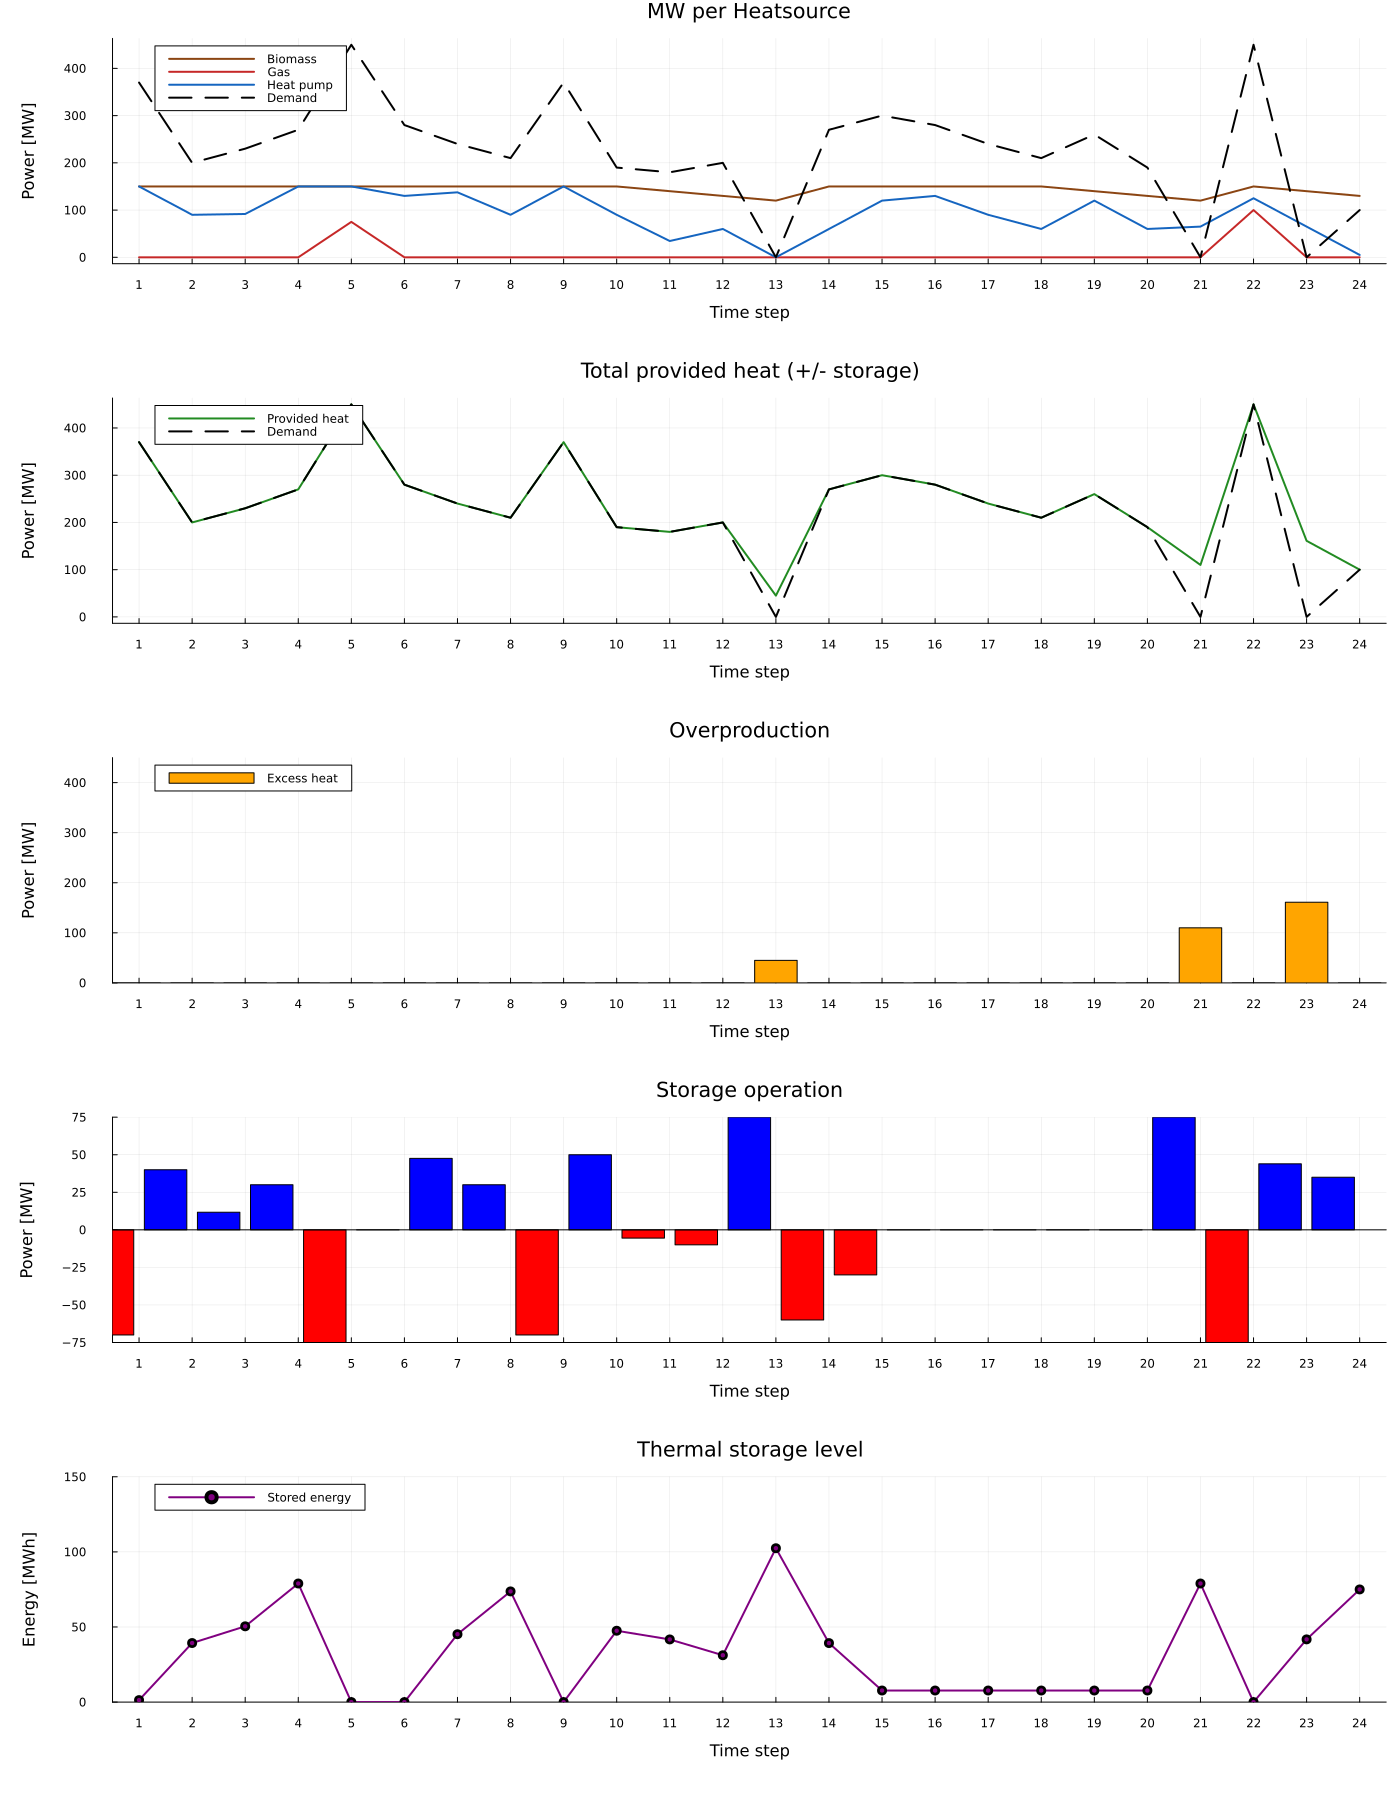

In [ ]:
#plot opt2
xmin = 0.5
xmax = N + 0.5
# PLOT RESULTS - MODEL WITH STORAGE
x2_result = value.(x2)

biomass = x2_result[1,:]
gas = x2_result[2,:]
heatpump = x2_result[3,:]

charge_result = value.(charge)
discharge_result = value.(discharge)
storage_level = value.(E)
storage_movement = discharge_result .- charge_result
# positive = storage gives heat
# negative = storage gets heat

# total heat provided to demand
total_generation = biomass .+ gas .+ heatpump
provided_heat = total_generation .+ storage_movement

# heat produced above actual demand
# excess_heat = max.(provided_heat .- d, 0)
excess_heat = value.(excessHeat)

# 1. HEAT SOURCES
p_sources = plot(1:N, 
    biomass,    label="Biomass",
    color="#8B4513",lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="MW per Heatsource",
    xticks=1:N,
    grid=true,
    xlim = (xmin,xmax))
plot!(p_sources,1:N,gas, label="Gas",color="#C62828",lw=2)
plot!(p_sources,1:N, heatpump, label="Heat pump", color="#1565C0",lw=2)
plot!(p_sources,1:N,d, label="Demand",color=:black,lw=2,linestyle=:dash)

# 2. TOTAL PROVIDED HEAT (with storage)
p_total = plot(1:N,
    provided_heat,  label="Provided heat",
    color="#228B22",lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Total provided heat (+/- storage)",
    xticks=1:N,
    grid=true,
    xlim = (xmin,xmax),
    legend=:topleft)
plot!(p_total,1:N,
    d,          label="Demand",
    color=:black,lw=2,linestyle=:dash)

    
# 3. EXCESS HEAT
p_excess = bar(1:N,
    excess_heat,
    label="Excess heat",color=:orange,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Overproduction",
    xticks=1:N,
    grid=true,
    ylims=(0,ymax),
    xlim = (xmin,xmax),
    legend=:topleft
    )

# 4. STORAGE MOVEMENT
movement_time = (1:N) .- 0.5
bar_colors = [-storage_movement[i] >= 0 ? :blue : :red     for i in 1:length(storage_movement)]
# storage_movement[1] = 0

p_movement = bar(
    movement_time,
    -storage_movement,
    label="",
    color=bar_colors,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Storage operation",
    xticks=1:N,
    grid=true,
    xlim = (xmin,xmax))

hline!(p_movement,[0],color=:black,lw=1,label="")

# 5. STORAGE LEVEL
p_storage = plot(1:N,
    storage_level,
    label="Stored energy",
    color=:purple,lw=2,
    marker=:circle,
    xlabel="Time step",
    ylabel="Energy [MWh]",
    title="Thermal storage level",
    xticks=1:N,
    grid=true,
    ylims=(0,E_max),
    xlim = (xmin,xmax),
    legend=:topleft)


# COMBINED PLOT
p_combined = plot(
    p_sources, p_total, p_excess, p_movement, p_storage,
    layout=@layout([
        a
        b
        c
        d
        e
        ]),
    link=:x,
    left_margin=12mm,
    bottom_margin=8mm,
    size=(1400,1800))

display(p_combined)

## Conclusion

*General:*

- Biomass covers most of the base load
- Heat pump supports medium demand
- Gas mainly covers peak demand

*Storage:*

- **Storage** reduces expensive peak production
- Ramp constraints can cause overproduction


- 150 MWh storage capacity appears oversized

**Possible options to improve the system:**
- increase Charging/discharging power
- reduce storage capacity
- Minimum reserve level *(50 MWh)* could improve reliability
